In [1]:
import json

In [2]:
with open('1-raw/ustad_360_others.json', 'r') as f:
    others = json.load(f)

In [3]:
len(others)

14014

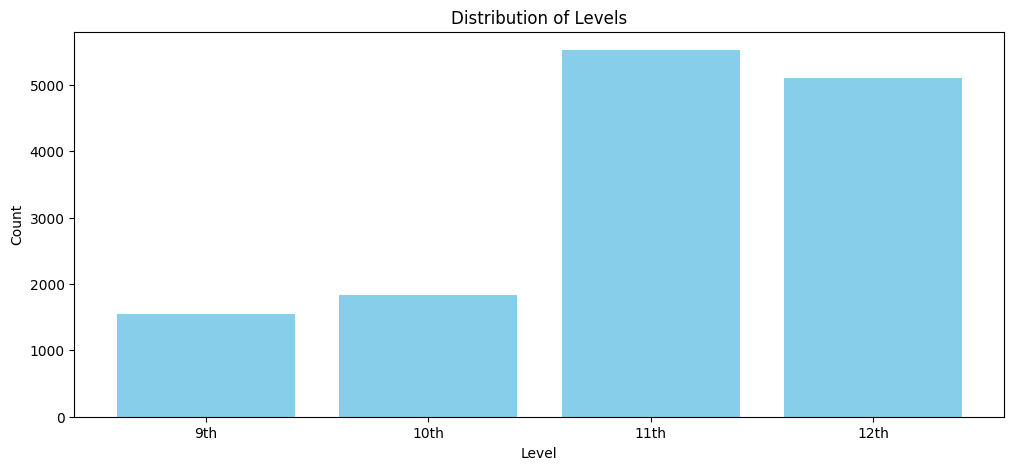

In [4]:
# check distribution of levels and subdomains through bar plots.
import matplotlib.pyplot as plt
from collections import Counter

levels = [item['level'] for item in others]
level_counts = Counter(levels)

plt.figure(figsize=(12, 5))
plt.bar(level_counts.keys(), level_counts.values(), color='skyblue')
plt.title('Distribution of Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

/var/folders/hg/42wj3hjn0dl6x_s469yvq33w0000gn/T/ipykernel_93796/565050165.py:11: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hg/42wj3hjn0dl6x_s469yvq33w0000gn/T/ipykernel_93796/565050165.py:11: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/Users/sarfrazahmad/.pyenv/versions/3.11.13/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sarfrazahmad/.pyenv/versions/3.11.13/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)


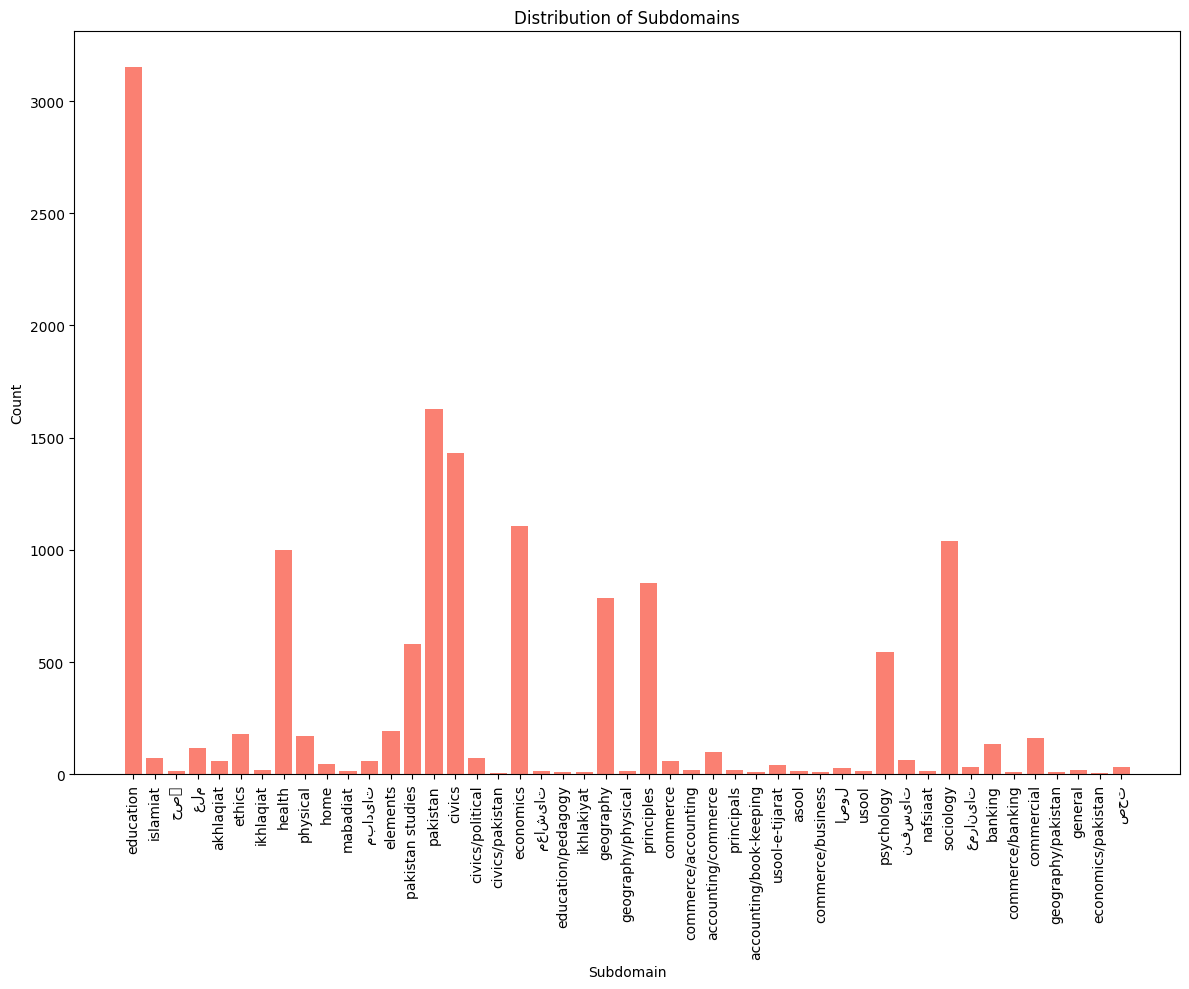

In [5]:
subdomains = [item['subdomain'] for item in others]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
# find unique subdomains
unique_subdomains = set(subdomains)
unique_subdomains


{'accounting/book-keeping',
 'accounting/commerce',
 'akhlaqiat',
 'asool',
 'banking',
 'civics',
 'civics/pakistan',
 'civics/political',
 'commerce',
 'commerce/accounting',
 'commerce/banking',
 'commerce/business',
 'commercial',
 'economics',
 'economics/pakistan',
 'education',
 'education/pedagogy',
 'elements',
 'ethics',
 'general',
 'geography',
 'geography/pakistan',
 'geography/physical',
 'health',
 'home',
 'ikhlakiyat',
 'ikhlaqiat',
 'islamiat',
 'mabadiat',
 'nafsiaat',
 'pakistan',
 'pakistan studies',
 'physical',
 'principals',
 'principles',
 'psychology',
 'sociology',
 'usool',
 'usool-e-tijarat',
 'اصول',
 'حصہ',
 'صحت',
 'علم',
 'عمرانیات',
 'مبادیات',
 'معاشیات',
 'نفسیات'}

In [7]:
# let's now map subdomain to following update subdomain:
# ['civics', 'civics/pakistan', 'civics/political', 'حصہ'] -> 'civics'
# ['commerce', 'commerce/accounting', 'commerce/banking', 'commerce/business', 'commercial', 'usool', 'usool-e-tijarat', 'accounting/book-keeping', 'accounting/commerce', 'asool', 'banking'] -> 'commerce'
# ['economics', 'economics/pakistan', 'اصول', 'معاشیات', 'principals', 'principles'] -> 'economics'

# ['education', 'education/pedagogy', 'علم'] -> 'education'

# ['ethics', 'akhlaqiat', 'ikhlakiyat', 'ikhlaqiat'] -> 'ethics'

# ['general', 'geography', 'geography/pakistan', 'geography/physical'] -> 'geography'

# ['health', 'physical', 'صحت'] -> 'health and physical education'
# ['home', 'elements', 'mabadiat', 'مبادیات'] -> 'home economics'

# ['islamiat'] -> 'islamiat'
# ['nafsiaat', 'psychology', 'نفسیات'] -> 'psychology and clinical education'
# ['pakistan', 'pakistan studies'] -> 'pakistan'
# ['sociology', 'عمرانیات'] -> 'sociology'

subdomain_mapping = {
    'civics': 'civics',
    'civics/pakistan': 'civics',
    'civics/political': 'civics',
    'حصہ': 'civics',
    'commerce': 'commerce',
    'commerce/accounting': 'commerce',
    'commerce/banking': 'commerce',
    'commerce/business': 'commerce',
    'commercial': 'commerce',
    'usool': 'commerce',
    'usool-e-tijarat': 'commerce',
    'accounting/book-keeping': 'commerce',
    'accounting/commerce': 'commerce',
    'asool': 'commerce',
    'banking': 'commerce',
    'economics': 'economics',
    'economics/pakistan': 'economics',
    'اصول': 'economics',
    'معاشیات': 'economics',
    'principals': 'economics',
    'principles': 'economics',
    'education': 'education',
    'education/pedagogy': 'education',
    'علم': 'education',
    'ethics': 'ethics',
    'akhlaqiat': 'ethics',
    'ikhlakiyat': 'ethics',
    'ikhlaqiat': 'ethics',
    'general': 'geography',
    'geography': 'geography',
    'geography/pakistan': 'geography',
    'geography/physical': 'geography',
    'health': 'health and physical education',
    'physical': 'health and physical education',
    'صحت': 'health and physical education',
    'home': 'home economics',
    'elements': 'home economics',
    'mabadiat': 'home economics',
    'مبادیات': 'home economics',
    'islamiat': 'islamiat',
    'nafsiaat': 'psychology and clinical education',
    'psychology': 'psychology and clinical education',
    'نفسیات': 'psychology and clinical education',
    'pakistan': 'pakistan studies',
    'pakistan studies': 'pakistan studies',
    'sociology': 'sociology',
    'عمرانیات': 'sociology'
}

mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the subdomain key in others with mapped subdomain
for item in others:
    item['subdomain'] = subdomain_mapping.get(item['subdomain'], item['subdomain'])

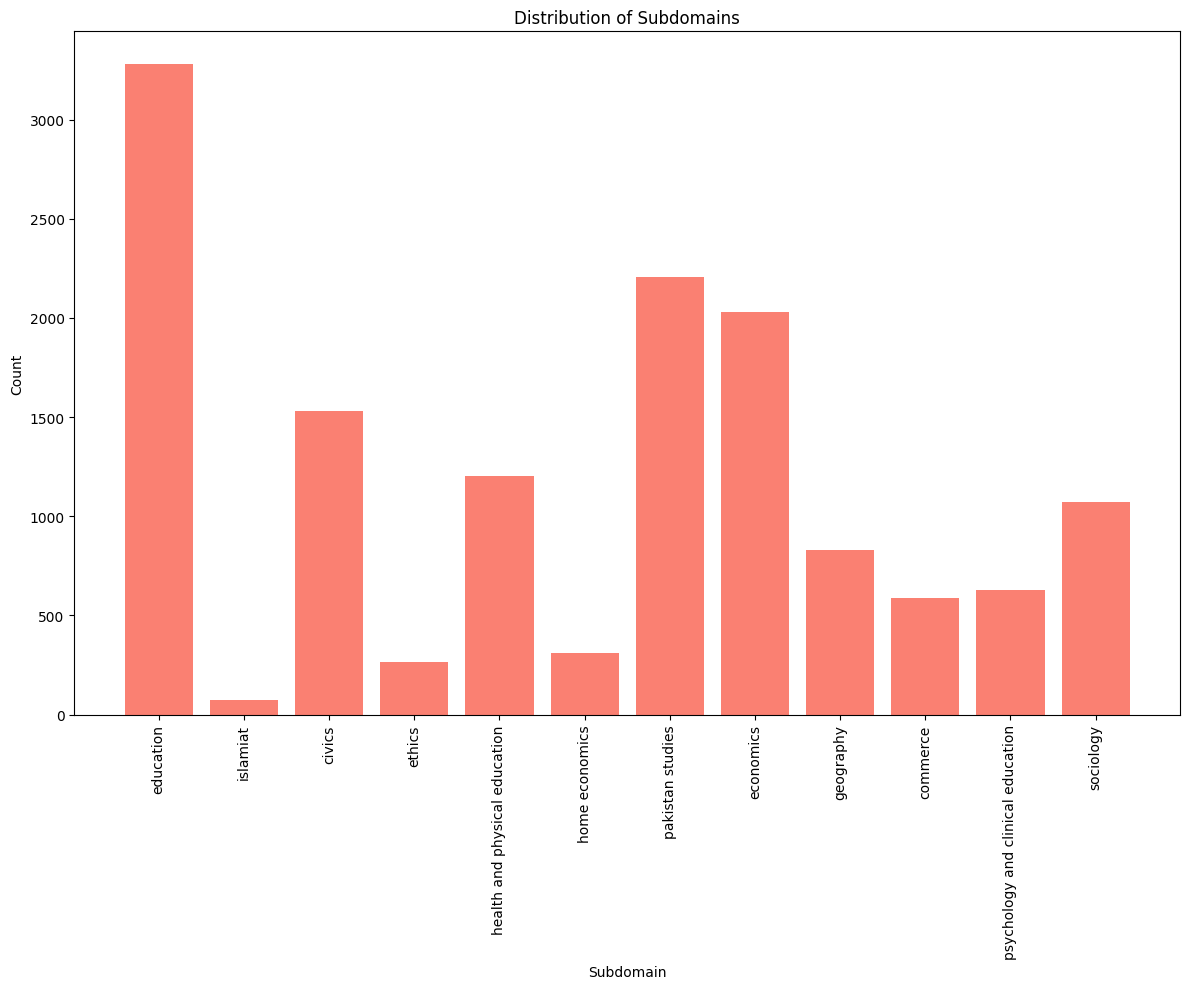

In [8]:
subdomains = [item['subdomain'] for item in others]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
# update level key as follow:
# 9th-> SSC-I, 10th-> SSC-II, 11th-> HSSC-I, 12th-> HSSC-II
level_mapping = {
    '9th': 'SSC-I',
    '10th': 'SSC-II',
    '11th': 'HSSC-I',
    '12th': 'HSSC-II'
}

mapped_levels = [level_mapping.get(level, level) for level in levels]
mapped_level_counts = Counter(mapped_levels)
# update the level key in others with mapped level
for item in others:
    item['level'] = level_mapping.get(item['level'], item['level'])

In [10]:
others[0]

{'question_number': 1,
 'question': 'علم کے معنی ہیں :',
 'options': {'A': 'دیکھنا', 'B': 'جاننا', 'C': 'پھلنا پھولنا', 'D': 'سوچنا'},
 'has_image': False,
 'image_bbox': None,
 'domain': 'Education SSC-A (Part-I)',
 'subdomain': 'education',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-I',
 'page': 1,
 'source_url': '',
 'source_image': 'Education%209-BWP-22_page_0001.jpg',
 'folder': 'Education%209-BWP-22',
 'provider': 'gemini',
 'model': 'gemini-3-flash-preview'}

In [11]:
# add source_name key to each item in others with value 'ustad_360'
for item in others:
    item['source'] = 'Ustad 360'

In [12]:
with open('2-processed/ustad_360_others.json', 'w', encoding='utf-8') as f:
    json.dump(others, f, ensure_ascii=False, indent=4)